2.

In [22]:
url = "https://boston.craigslist.org/search/sss?excats=5-15-73-3-5-21-13-28-4-3-9-7-4-13-1&postal=02446&query=Toyota%20Camry&search_distance=100#search=2~gallery~0~44.2582~-77.4840~39.3101~-64.1220"

3.

In [23]:
import requests
from bs4 import BeautifulSoup as bs
import pandas as pd
import numpy as np
import re

In [24]:
response = requests.get(url)
soup = bs(response.text, 'html.parser')
titles = soup.find_all("div", class_="title")

is_toyota_camry = []
for title in titles:
  if "toyota camry" in title.text.lower():
    is_toyota_camry.append(title.text)


In [25]:
lists = soup.find_all("li", class_="cl-static-search-result")
titles = []
locations = []
prices = []

df = pd.DataFrame(columns=["Description", "Location", "Price","Year"])


for l in lists:
  check = l.find("div", class_="title")
  if check and check.text in is_toyota_camry:
    title = check.text
    location_element = l.find("div", class_="location")
    location = location_element.get_text(strip=True) if location_element else np.nan
    price_element = l.find("div", class_="price")
    str_price = price_element.text
    price = int(str_price.replace("$", "").replace(",", "")) if str_price != "$0" else np.nan

    titles.append(title)
    locations.append(location)
    prices.append(price)

df['Description'] = titles
df['Location'] = locations
df['Price'] = prices
df['Price'] = df['Price'].astype("Int64")

YEAR_RE = re.compile(r'\b(19[5-9]\d|20[0-3]\d)\b')

def extract_year(title: str):
    m = YEAR_RE.search(title)
    return int(m.group(0)) if m else np.nan

df['Year'] = df['Description'].apply(extract_year).astype("Int64")
df


,Description,Location,Price,Year
0,2014 Toyota Camry LE,Worcester,9400,2014
1,2007 Toyota Camry Hybrid,Hadley,3900,2007
2,2004 Toyota Camry,Providence,2000,2004
3,2020 Toyota Camry - Financing Available!,NaN,17999,2020
4,Toyota camry 2018,Fitchburg,15000,2018
...,...,...,...,...
101,"$1,000 2005 Toyota Camry",Bloomfield,1000,2005
102,1999 Toyota Camry Solara SE: Sleek Silver with...,Providence,4500,1999
103,"2008 Toyota Camry, blue",Northampton,6400,2008
104,2007 Toyota Camry,Northampton,6000,2007


4.

In [26]:
median = df['Year'].median()
df['Year'] = df['Year'].fillna(int(df['Year'].median()))
df

,Description,Location,Price,Year
0,2014 Toyota Camry LE,Worcester,9400,2014
1,2007 Toyota Camry Hybrid,Hadley,3900,2007
2,2004 Toyota Camry,Providence,2000,2004
3,2020 Toyota Camry - Financing Available!,NaN,17999,2020
4,Toyota camry 2018,Fitchburg,15000,2018
...,...,...,...,...
101,"$1,000 2005 Toyota Camry",Bloomfield,1000,2005
102,1999 Toyota Camry Solara SE: Sleek Silver with...,Providence,4500,1999
103,"2008 Toyota Camry, blue",Northampton,6400,2008
104,2007 Toyota Camry,Northampton,6000,2007


5.

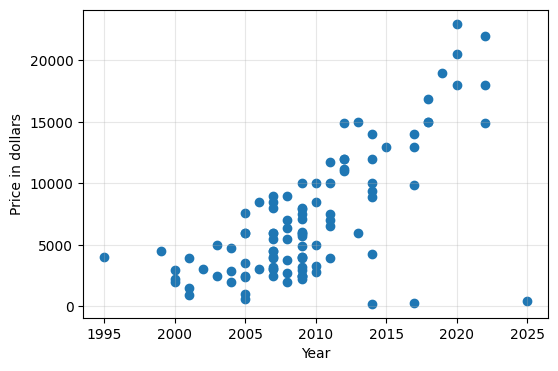

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter(df['Year'], df['Price'])
plt.title("")
plt.xlabel("Year")
plt.ylabel("Price in dollars")
plt.grid(True, alpha=0.3)
plt.show()

6.

In [28]:
corr = df["Year"].corr(df["Price"], method="pearson")
print(corr)

0.6865658305751562
